![image.png](https://i.imgur.com/a3uAqnb.png)

## Bootstrap Your Own Latent

BYOL learns image representations from two augmented views of the same image.

Unlike SimCLR, BYOL does not use negative pairs. It uses:

- An **online network**
- A slowly updated **target network**

### Paper

**Title:** *Bootstrap Your Own Latent: A New Approach to Self-Supervised Learning*

[Read the official NeurIPS paper](https://papers.nips.cc/paper/2020/file/f3ada80d5c4ee70142b17b8192b2958e-Paper.pdf)


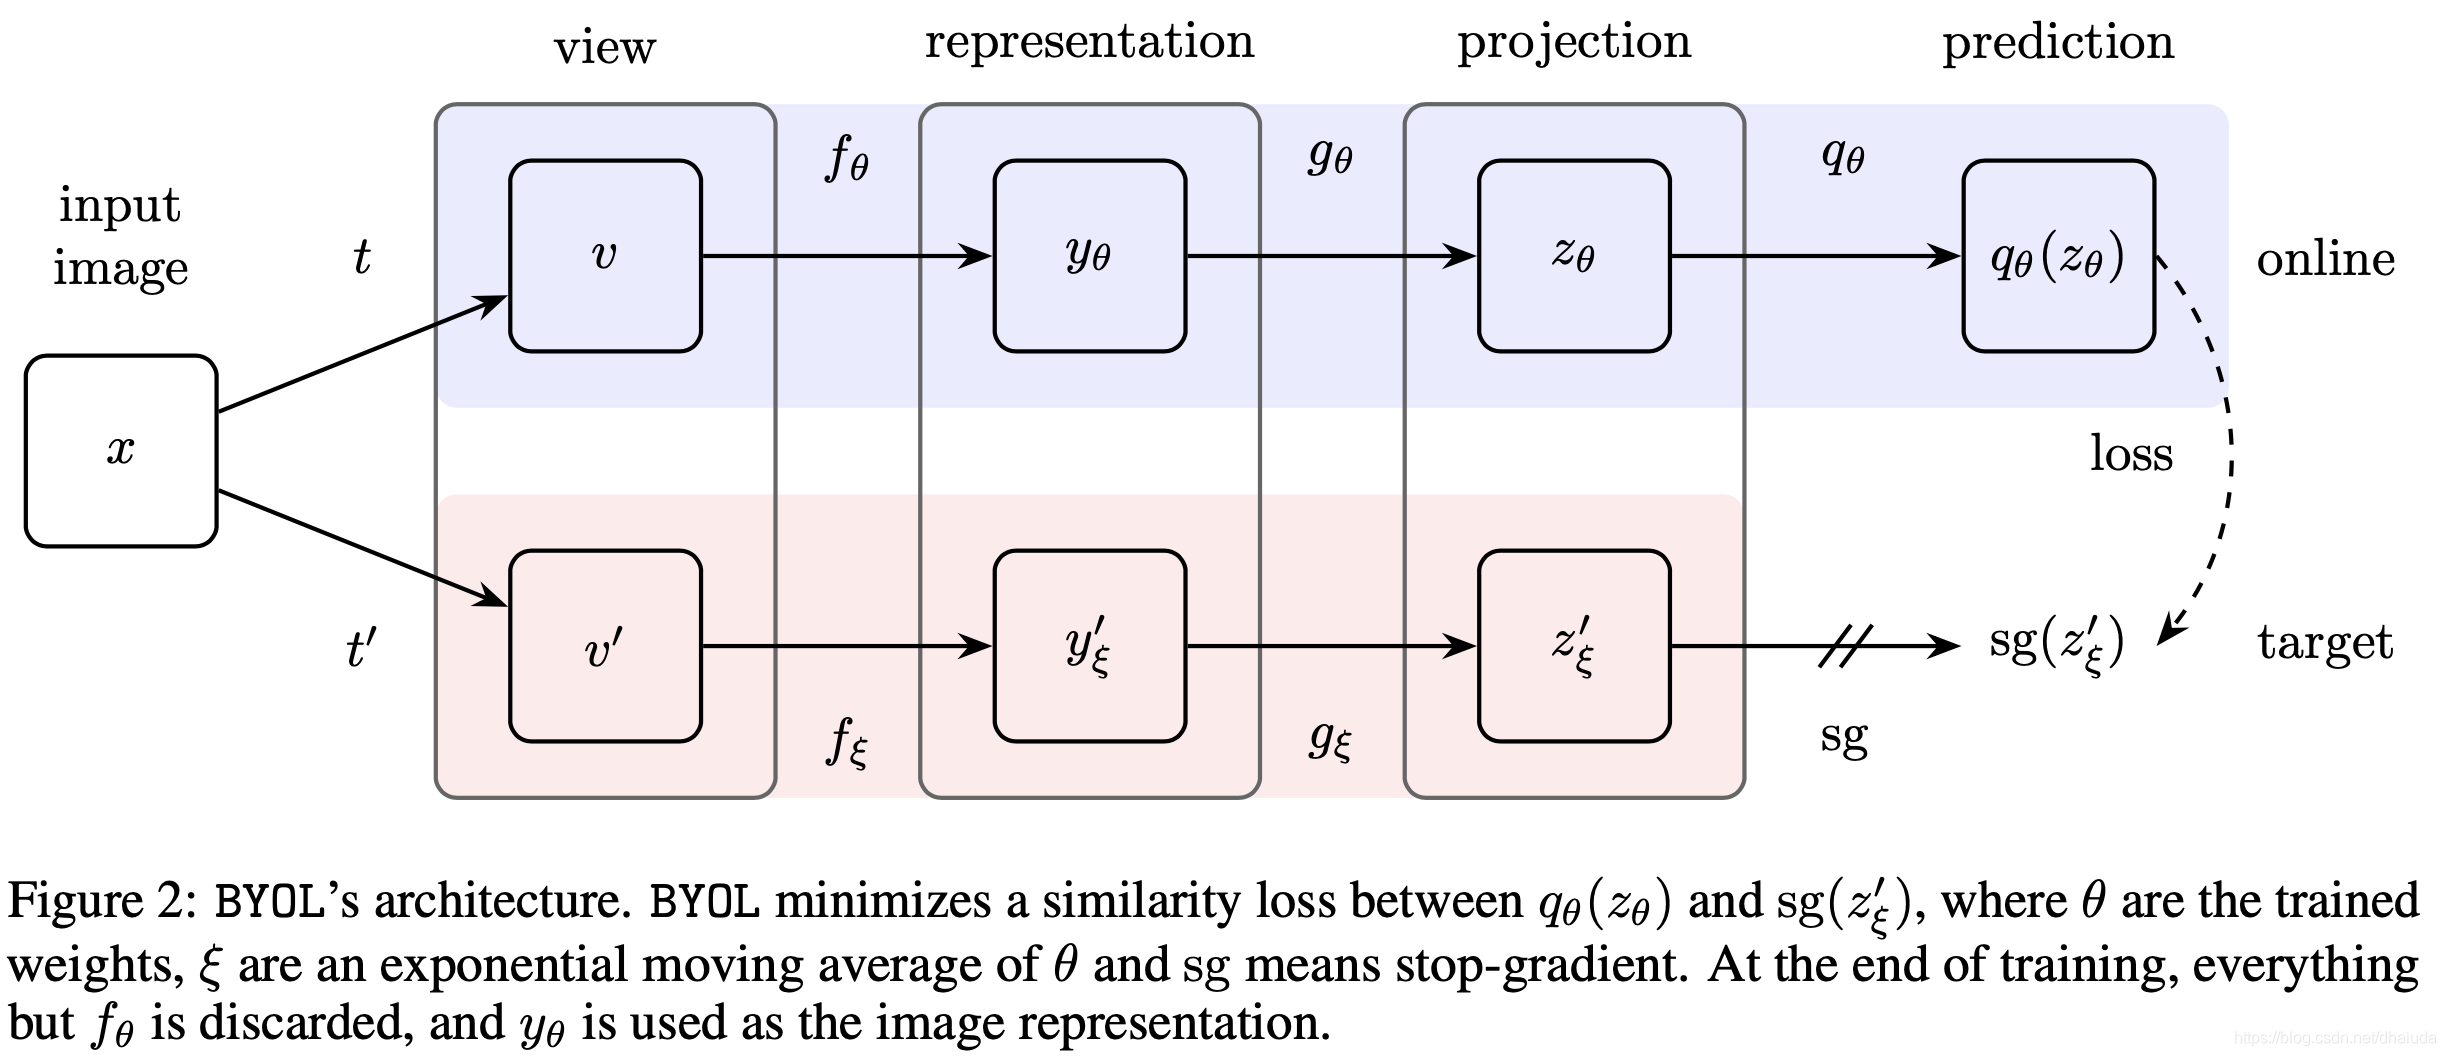

In [ ]:
import os
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
from torchvision.datasets import STL10
from torchvision import transforms

from torch.utils.data import DataLoader
from tqdm import tqdm

import matplotlib.pyplot as plt

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

NUM_WORKERS = min(4, os.cpu_count() or 1)

print("Device:", device)
print("Workers:", NUM_WORKERS)

Device: cuda
Workers: 4


## 2. Load the STL-10 Dataset

We use the unlabeled STL-10 images for BYOL pretraining.


In [ ]:
dataset = STL10(
    root="./data",
    split="unlabeled",
    download=True
)

print("Number of unlabeled images:", len(dataset))

Number of unlabeled images: 100000


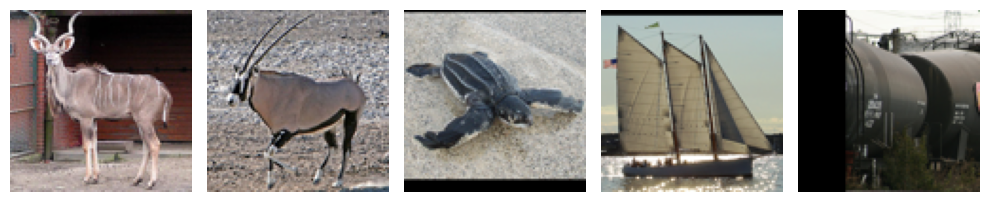

In [ ]:
plt.figure(figsize=(10, 4))

for i in range(5):
    image, _ = dataset[i]

    plt.subplot(1, 5, i + 1)
    plt.imshow(image)
    plt.axis("off")

plt.tight_layout()
plt.show()

## 3. Create Two Augmented Views

BYOL creates two different views of the same image. These views are processed by the online and target networks.


In [ ]:
byol_transform = transforms.Compose([
    transforms.RandomResizedCrop(96),
    transforms.RandomHorizontalFlip(),

    transforms.RandomApply([
        transforms.ColorJitter(
            brightness=0.4,
            contrast=0.4,
            saturation=0.4,
            hue=0.1
        )
    ], p=0.8),

    transforms.RandomGrayscale(p=0.2),
    transforms.GaussianBlur(kernel_size=9),

    transforms.ToTensor()
])

In [ ]:
class TwoViews:
    def __init__(self, transform):
        self.transform = transform

    def __call__(self, image):
        return self.transform(image), self.transform(image)

In [ ]:
byol_dataset = STL10(
    root="./data",
    split="unlabeled",
    download=True,
    transform=TwoViews(byol_transform)
)

train_loader = DataLoader(
    byol_dataset,
    batch_size=128,
    shuffle=True,
    drop_last=True,
    num_workers=0,
    pin_memory=True
)

print("Number of batches:", len(train_loader))

Number of batches: 781


## 4. Build the BYOL Networks

BYOL uses an online network, a target network, and a predictor. The target network is updated slowly from the online network.


In [ ]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=512, output_dim=256):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
class BYOLModel(nn.Module):
    def __init__(self):
        super().__init__()

        # Online encoder
        self.online_encoder = torchvision.models.resnet18(weights=None)
        feature_dim = self.online_encoder.fc.in_features
        self.online_encoder.fc = nn.Identity()

        # Online projector and predictor
        self.online_projector = MLP(feature_dim)
        self.predictor = MLP(256, hidden_dim=512, output_dim=256)

        # Target encoder and projector
        self.target_encoder = copy.deepcopy(self.online_encoder)
        self.target_projector = copy.deepcopy(self.online_projector)

        # Target network is not trained by gradients
        for parameter in self.target_encoder.parameters():
            parameter.requires_grad = False

        for parameter in self.target_projector.parameters():
            parameter.requires_grad = False

    def forward_online(self, x):
        features = self.online_encoder(x)
        projection = self.online_projector(features)
        prediction = self.predictor(projection)

        return prediction

    @torch.no_grad()
    def forward_target(self, x):
        features = self.target_encoder(x)
        projection = self.target_projector(features)

        return projection

In [ ]:
byol_model = BYOLModel().to(device)

print("BYOL model created.")

BYOL model created.


## 5. BYOL Loss and Target Update

BYOL matches the online prediction with the target projection. The target network is updated using an exponential moving average.


In [ ]:
def byol_loss(prediction, target):
    prediction = F.normalize(prediction, dim=1)
    target = F.normalize(target, dim=1)
# BYOL loss: L = 2 - 2·cos(p, z)
    return 2 - 2 * (prediction * target).sum(dim=1).mean()

In [ ]:
@torch.no_grad()
def update_target_network(model, momentum=0.99):
    for online_param, target_param in zip(
        model.online_encoder.parameters(),
        model.target_encoder.parameters()
    ):# ξ_new = 0.99 × ξ_old + 0.01 × θ
        target_param.data = (
            momentum * target_param.data
            + (1 - momentum) * online_param.data
        )

    for online_param, target_param in zip(
        model.online_projector.parameters(),
        model.target_projector.parameters()
    ):
        target_param.data = (
            momentum * target_param.data
            + (1 - momentum) * online_param.data
        )

## 6. Train BYOL

The online network learns from two augmented views, while the target network is updated using momentum.


In [ ]:
optimizer = optim.AdamW(
    list(byol_model.online_encoder.parameters())
    + list(byol_model.online_projector.parameters())
    + list(byol_model.predictor.parameters()),
    lr=3e-4,
    weight_decay=1e-4
)

EPOCHS = 10
MOMENTUM = 0.99

byol_losses = []

for epoch in range(EPOCHS):
    byol_model.train()
    total_loss = 0.0

    progress_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/{EPOCHS}"
    )

    for views, _ in progress_bar:
        view1, view2 = views

        view1 = view1.to(device)
        view2 = view2.to(device)

        optimizer.zero_grad()

        # Online predictions
        prediction1 = byol_model.forward_online(view1)
        prediction2 = byol_model.forward_online(view2)

        # Target projections
        with torch.no_grad():
            target1 = byol_model.forward_target(view1)
            target2 = byol_model.forward_target(view2)

        # Symmetric BYOL loss
        loss1 = byol_loss(prediction1, target2)
        loss2 = byol_loss(prediction2, target1)
        loss = 0.5 * (loss1 + loss2)

        loss.backward()
        optimizer.step()

        # Update target network
        update_target_network(
            byol_model,
            momentum=MOMENTUM
        )

        total_loss += loss.item()
        progress_bar.set_postfix(loss=f"{loss.item():.4f}")

    average_loss = total_loss / len(train_loader)
    byol_losses.append(average_loss)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} - "
        f"Average loss: {average_loss:.4f}"
    )

Epoch 1/10: 100%|██████████| 781/781 [51:39<00:00,  3.97s/it, loss=0.3975]


Epoch 1/10 - Average loss: 0.4934


Epoch 2/10: 100%|██████████| 781/781 [54:14<00:00,  4.17s/it, loss=0.3331] 


Epoch 2/10 - Average loss: 0.3579


Epoch 3/10: 100%|██████████| 781/781 [53:39<00:00,  4.12s/it, loss=0.3314] 


...

Epoch 8/10 - Average loss: 0.2357


Epoch 9/10: 100%|██████████| 781/781 [56:18<00:00,  4.33s/it, loss=0.1896]  


Epoch 9/10 - Average loss: 0.2298


Epoch 10/10: 100%|██████████| 781/781 [46:59<00:00,  3.61s/it, loss=0.2485]

Epoch 10/10 - Average loss: 0.2282


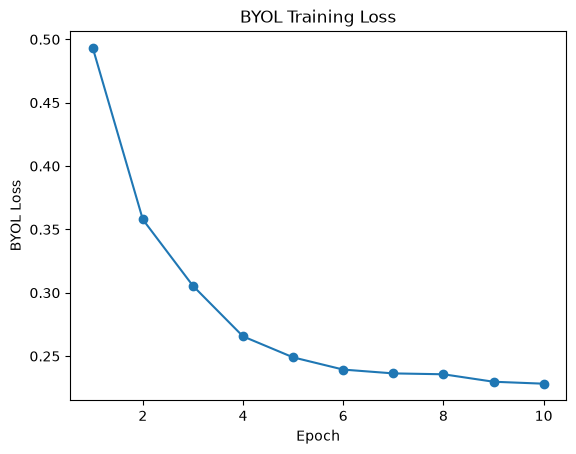

In [ ]:
plt.plot(
    range(1, EPOCHS + 1),
    byol_losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("BYOL Loss")
plt.title("BYOL Training Loss")
plt.show()

## 7. Save the BYOL Model

Save the trained BYOL model so the learned encoder can be reused for evaluation.


In [ ]:
torch.save(
    byol_model.state_dict(),
    "byol_stl10.pth"
)

print("BYOL model saved.")

BYOL model saved.


## 8. Prepare Labeled Data

The labeled STL-10 training and test sets are used to evaluate the frozen BYOL encoder.


In [ ]:
eval_transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = STL10(
    root="./data",
    split="train",
    download=True,
    transform=eval_transform
)

test_dataset = STL10(
    root="./data",
    split="test",
    download=True,
    transform=eval_transform
)

train_eval_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

test_eval_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("Training images:", len(train_dataset))
print("Test images:", len(test_dataset))

Training images: 5000
Test images: 8000


## 9. Linear Evaluation

Freeze the BYOL encoder and train a linear classifier using labeled STL-10 images.


In [ ]:
# Freeze the BYOL encoder
for parameter in byol_model.online_encoder.parameters():
    parameter.requires_grad = False

byol_model.online_encoder.eval()

# Linear classifier for 10 STL-10 classes
byol_classifier = nn.Linear(512, 10).to(device)

criterion = nn.CrossEntropyLoss()

classifier_optimizer = optim.Adam(
    byol_classifier.parameters(),
    lr=1e-3
)

In [ ]:
LINEAR_EPOCHS = 20

for epoch in range(LINEAR_EPOCHS):
    byol_classifier.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_eval_loader:
        images = images.to(device)
        labels = labels.to(device)

        classifier_optimizer.zero_grad()

        with torch.no_grad():
            features = byol_model.online_encoder(images)

        logits = byol_classifier(features)
        loss = criterion(logits, labels)

        loss.backward()
        classifier_optimizer.step()

        total_loss += loss.item()

        predictions = logits.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    average_loss = total_loss / len(train_eval_loader)
    accuracy = 100 * correct / total

    print(
        f"Epoch {epoch + 1}/{LINEAR_EPOCHS} - "
        f"Loss: {average_loss:.4f} - "
        f"Accuracy: {accuracy:.2f}%"
    )

Epoch 1/20 - Loss: 1.2107 - Accuracy: 54.14%
Epoch 2/20 - Loss: 1.1875 - Accuracy: 55.18%
Epoch 3/20 - Loss: 1.2154 - Accuracy: 53.80%
Epoch 4/20 - Loss: 1.1914 - Accuracy: 54.96%
Epoch 5/20 - Loss: 1.1893 - Accuracy: 54.66%
Epoch 6/20 - Loss: 1.1828 - Accuracy: 55.10%
Epoch 7/20 - Loss: 1.1563 - Accuracy: 56.24%
Epoch 8/20 - Loss: 1.1571 - Accuracy: 55.74%
Epoch 9/20 - Loss: 1.1527 - Accuracy: 56.86%
Epoch 10/20 - Loss: 1.1477 - Accuracy: 57.54%
Epoch 11/20 - Loss: 1.1523 - Accuracy: 56.28%
Epoch 12/20 - Loss: 1.1484 - Accuracy: 57.64%
Epoch 13/20 - Loss: 1.1477 - Accuracy: 57.08%
Epoch 14/20 - Loss: 1.1334 - Accuracy: 57.48%
Epoch 15/20 - Loss: 1.1433 - Accuracy: 56.40%
Epoch 16/20 - Loss: 1.1254 - Accuracy: 57.76%
Epoch 17/20 - Loss: 1.1363 - Accuracy: 58.18%
Epoch 18/20 - Loss: 1.1240 - Accuracy: 57.60%
Epoch 19/20 - Loss: 1.1349 - Accuracy: 58.48%
Epoch 20/20 - Loss: 1.1374 - Accuracy: 57.84%


## 10. Evaluate BYOL

Evaluate the frozen BYOL encoder and trained classifier on the STL-10 test set.


In [ ]:
byol_classifier.eval()
byol_model.online_encoder.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_eval_loader:
        images = images.to(device)
        labels = labels.to(device)

        features = byol_model.online_encoder(images)
        logits = byol_classifier(features)

        predictions = logits.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

byol_test_accuracy = 100 * correct / total

print(f"BYOL Test Accuracy: {byol_test_accuracy:.2f}%")

BYOL Test Accuracy: 56.86%


## Exercises

* Change the momentum value and compare the BYOL accuracy.
* Use fewer labeled images to train the classifier.
* Train BYOL for more epochs.
* Compare BYOL with SimCLR using the same settings.


Contributed by :Lama Ayash